# Model Interpretation — LightGBM v1

## 1. Загрузка модели и данных


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
preprocessor = joblib.load(
    "../models/preprocessor.joblib"
)

model = joblib.load(
    "../models/lightgbm_candidate.joblib"
)

with open("../models/model_metadata.json", "r") as f:
    metadata = json.load(f)

val = pd.read_parquet(
    "../data/processed/validation.parquet"
)

drop_cols = metadata["drop_cols"]
categorical_cols = metadata["categorical_cols"]

X_val = val.drop(columns=drop_cols)
y_val = val["is_canceled"]

for col in categorical_cols:
    X_val[col] = (
        X_val[col]
        .astype("object")
        .where(X_val[col].notna(), np.nan)
    )

X_val_enc = preprocessor.transform(X_val)

## 2. Feature importance


In [3]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

print("Количество признаков после preprocessing:", len(feature_names))
print(feature_names[:20])

Количество признаков после preprocessing: 801
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_children', 'has_agent', 'has_company', 'has_agent_or_company', 'total_guests']


In [4]:
importance = model.booster_.feature_importance(
    importance_type="gain"
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
228,deposit_type_Non Refund,316196.453359
0,lead_time,123398.838543
227,deposit_type_No Deposit,91852.863945
165,country_PRT,80142.205182
14,total_of_special_requests,71732.452127
10,previous_cancellations,62665.892200
13,required_car_parking_spaces,55207.995706
210,market_segment_Online TA,53534.474407
1,arrival_date_year,47778.520711
12,adr,47057.478032


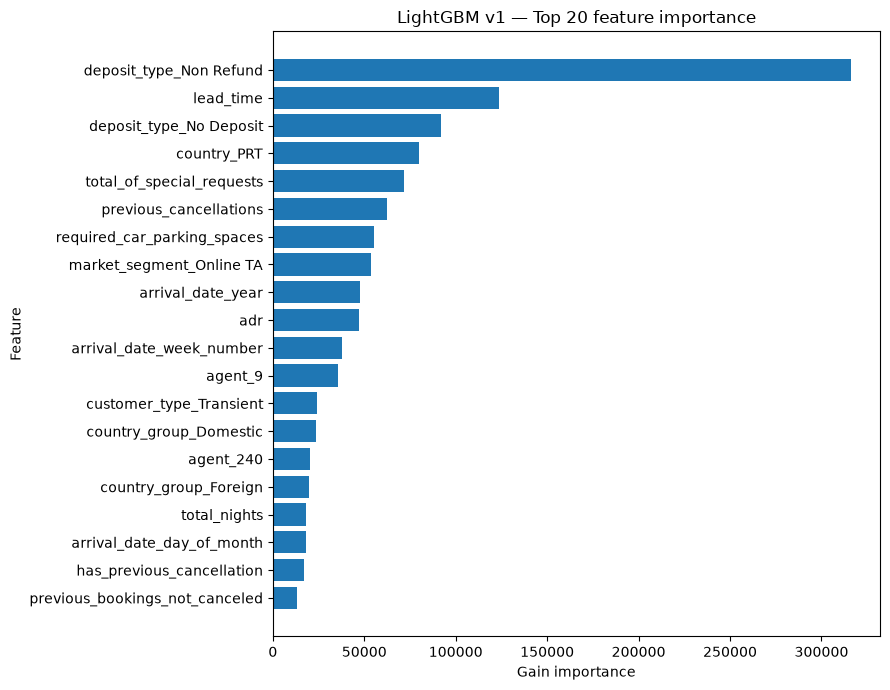

In [5]:
top_features = feature_importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.title("LightGBM v1 — Top 20 feature importance")
plt.tight_layout()
plt.show()

### Вывод
`LightGBM v1` сильнее всего опирается на `deposit_type_Non Refund`, `lead_time`, `agent` и `country_PRT`. Многие из важных признаков заметно изменили распределение на будущем периоде, особенно `deposit_type` и `lead_time`. Это согласуется с падением качества модели на test. При этом feature importance показывает силу использования признака, но не направление его влияния, поэтому далее посмотрим SHAP

## 3. SHAP


Можно не считать на всех объектах, возьмем примерно 2000 строк

In [6]:
rng = np.random.default_rng(42)

sample_idx = rng.choice(
    X_val_enc.shape[0],
    size=min(2000, X_val_enc.shape[0]),
    replace=False
)

X_shap = X_val_enc[sample_idx]

if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

X_shap = pd.DataFrame(
    X_shap,
    columns=feature_names
)

In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_shap)

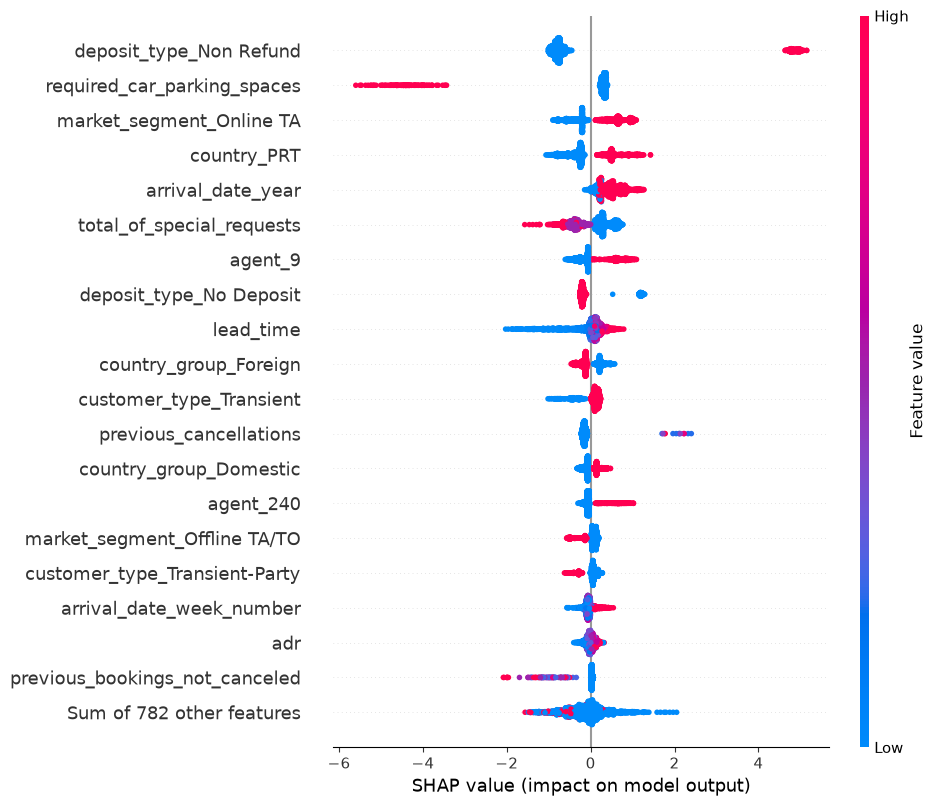

In [8]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

## Вывод
SHAP в целом подтвердил зависимости, которые были видны ещё на EDA. Наибольшее влияние на прогноз оказывает deposit_type_Non Refund. Также модель активно использует lead_time, тип рыночного сегмента, страну, специальные запросы, парковку и историю предыдущих бронирований.

После корректной обработки agent и company модель использует их как отдельные категории, а не как числовые значения.

Многие важные для модели признаки заметно изменили распределение на будущем периоде. Особенно сильно изменились deposit_type и lead_time, что хорошо согласуется с падением качества на test.